# Evaluate temporal structure and co-plant dependence

In [1]:
from __future__ import annotations
import warnings

from pathlib import Path
from collections import defaultdict
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import ks_2samp

import importlib

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../src')))
import GAMinferenceModels_V2 as gam_models

## Load and standardize models

In [2]:
# ----------------------------------------------------------
# Canonical conventions
# ----------------------------------------------------------

STATE_MAP = {
    "A": "A",
    "D": "D",
    "O": "O",
    "U": "O",
    0: "A",
    1: "D",
    2: "O",
}

TECH_COL_CANDIDATES = ["Technology", "UnitTypeCodeName"]


def _canonical_state(x):
    if pd.isna(x):
        return pd.NA
    return STATE_MAP.get(x, STATE_MAP.get(str(x), str(x)))


def _find_technology_column(df: pd.DataFrame) -> str | None:
    for c in TECH_COL_CANDIDATES:
        if c in df.columns:
            return c
    return None

In [3]:
# ----------------------------------------------------------
# Loading model bundles
# ----------------------------------------------------------

def load_models_from_paths(paths_models: dict[str, str], gam_models_module):
    """
    Load all non-naive models from joblib bundles.

    Returns
    -------
    models_loaded : dict[model_name -> dict with keys]
        {
            "models_by_region": ...,
            "scalers_by_region": ...,
            "metadata": ...
        }
    """
    models_loaded = {}

    for model_name, path in tqdm(paths_models.items(), desc="Loading models..."):
        models_by_region, scalers_by_region, metadata = gam_models_module.load_transition_model_bundle(path)
        if len(models_by_region) == 0:
            raise ValueError(f"No models found in bundle: {path}")
        
        # We actually have one model for all regions
        r = next(iter(models_by_region.keys()))
        models_loaded[model_name] = {
            "models": models_by_region[r],
            "scalers": scalers_by_region[r],
            "metadata": metadata,
        }

    return models_loaded


# ----------------------------------------------------------
# Loading naive model
# ----------------------------------------------------------

def load_naive_transition_table(path_naive: str) -> dict[str, pd.DataFrame]:
    """
    Load naive model csv and store one-row dataframe per state.

    Expected columns:
      State, pAA, pAD, pAO, pDA, pDD, pOA, pOO
    """
    print("Loading naive model...")
    df = pd.read_csv(path_naive)
    # add forbidden transitions explicitly
    if "pDO" not in df.columns:
        df["pDO"] = 0.0
    if "pOD" not in df.columns:
        df["pOD"] = 0.0

    required = {"State", "pAA", "pAD", "pAO", "pDA", "pDD", "pOA", "pOO"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Naive model file is missing columns: {missing}")

    df["State"] = df["State"].astype(str)

    naive_by_state = {}
    for state, sub in df.groupby("State"):
        naive_by_state[state] = sub.copy().reset_index(drop=True)

    return naive_by_state


# ----------------------------------------------------------
# Loading hourly test inputs
# ----------------------------------------------------------

def load_inputs_by_state(path_inputs: str) -> dict[str, pd.DataFrame]:
    """
    Load hourly covariate test set and split by geographical state.

    Required columns:
      Datetime_UTC, State, Stress
    Additional feature columns are preserved.
    """
    df = pd.read_csv(path_inputs, parse_dates=["Datetime_UTC"])

    required = {"Datetime_UTC", "State", "Stress"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Input feature file is missing columns: {missing}")

    df["State"] = df["State"].astype(str)
    df = df.sort_values(["State", "Datetime_UTC"]).reset_index(drop=True)

    inputs_by_state = {}
    for state, sub in tqdm(df.groupby("State"), desc="Loading inputs by state..."):
        sub = sub.copy()
        sub = sub.drop_duplicates(subset=["Datetime_UTC"])
        inputs_by_state[state] = sub.reset_index(drop=True)

    return inputs_by_state


# ----------------------------------------------------------
# Loading initial conditions
# ----------------------------------------------------------

def load_initial_conditions(path_initial_conditions: str) -> pd.DataFrame:
    """
    Load initial conditions and standardize state labels.

    Expected columns:
      Datetime_UTC, UnitID, Initial_gen_state, hours_in_state
    """
    print("Loading initial conditions...")
    df = pd.read_csv(path_initial_conditions, parse_dates=["Datetime_UTC"])

    required = {"Datetime_UTC", "UnitID", "Initial_gen_state", "hours_in_state"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Initial-condition file is missing columns: {missing}")

    df["UnitID"] = df["UnitID"].astype(str)
    df["Initial_gen_state"] = df["Initial_gen_state"].map(_canonical_state)
    df["hours_in_state"] = pd.to_numeric(df["hours_in_state"], errors="coerce")
    df = df.dropna(subset=["Initial_gen_state", "hours_in_state"]).copy()

    # enforce integer positive dwell
    df["hours_in_state"] = df["hours_in_state"].round().astype(int)
    df = df.loc[df["hours_in_state"] >= 1].copy()

    return df.reset_index(drop=True)

# ----------------------------------------------------------
# Generator Metadata Loader
# ----------------------------------------------------------
def load_generator_metadata(path_generator_metadata: str) -> pd.DataFrame:
    """
    Load generator metadata.

    Required columns:
      - UnitID
      - State
      - technology column (Technology or UnitTypeCodeName)
    """
    df = pd.read_csv(path_generator_metadata)

    required = {"UnitID", "State", "Datetime_UTC", "Technology"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Generator metadata file is missing columns: {missing}")

    tech_col = _find_technology_column(df)
    if tech_col is None:
        raise ValueError("Generator metadata file must contain either 'Technology' or 'UnitTypeCodeName' column.")
    
    gens = {'UnitID': [], 'Technology': [], 'Start_date': [], 'End_date': [], 'State': []}
    # for state in tqdm(df['State'].unique(), desc="Getting generators by state"):
    #     state_failures_df = df[df['State'] == state].copy()
    for unitID, unit_df in tqdm(df.groupby('UnitID'), desc="Getting generators by unit..."):
        start = unit_df['Datetime_UTC'].min()
        end = unit_df['Datetime_UTC'].max()
        gens['State'].append(unit_df['State'].iloc[0])
        gens['UnitID'].append(unitID)
        gens['Technology'].append(unit_df['Technology'].iloc[0])
        gens['Start_date'].append(start)
        gens['End_date'].append(end)

    return pd.DataFrame(gens)



# ----------------------------------------------------------
# Merge generator metadata + initial conditions
# ----------------------------------------------------------

def build_generators_per_state(
    inputs_by_state: dict[str, pd.DataFrame],
    initial_conditions_df: pd.DataFrame,
    generator_metadata_df: pd.DataFrame,
    technologies: list[str] | None = None,
) -> dict[str, pd.DataFrame]:
    """
    Build one generator table per geographical state.

    Required metadata columns:
      - UnitID
      - State
      - technology column (Technology or UnitTypeCodeName)

    Output columns:
      UnitID, State, Technology, Start_date, End_date, Start_state, Start_dwell_time
    """
    print("Building generator tables per state...")
    meta = generator_metadata_df.copy()
    meta["UnitID"] = meta["UnitID"].astype(str)
    meta["State"] = meta["State"].astype(str)

    tech_col = _find_technology_column(meta)
    if tech_col is None:
        raise ValueError("generator_metadata_df must contain either 'Technology' or 'UnitTypeCodeName'.")

    meta = meta.rename(columns={tech_col: "Technology"})
    meta.drop(columns=["Start_date"], inplace=True)

    # join initial conditions
    init = initial_conditions_df.copy().rename(columns={
        "Datetime_UTC": "Start_date",
        "Initial_gen_state": "Start_state",
        "hours_in_state": "Start_dwell_time",
    })

    gen = meta.merge(
        init[["UnitID", "Start_date", "Start_state", "Start_dwell_time"]],
        on="UnitID",
        how="inner",
        validate="one_to_one",
    )


    if technologies is not None:
        gen = gen.loc[gen["Technology"].isin(technologies)].copy()

    gen['State'] = gen['State'].astype(str).str.upper()


    generators_per_state = {}

    for state, inputs_df in inputs_by_state.items():
        state = state.upper()
        sub = gen.loc[gen["State"] == state].copy()
        if sub.empty:
            generators_per_state[state] = sub
            print(f"No generators found for state {state}, skipping...")
            continue

        # use input time range as scenario window
        end_date = inputs_df["Datetime_UTC"].max()
        sub["End_date"] = end_date

        # keep only units whose start date is not after the available inputs
        sub = sub.loc[sub["Start_date"] <= sub["End_date"]].copy()

        generators_per_state[state] = (
            sub[["UnitID", "State", "Technology", "Start_date", "End_date", "Start_state", "Start_dwell_time"]]
            .drop_duplicates(subset=["UnitID"])
            .reset_index(drop=True)
        )

    return generators_per_state


# ----------------------------------------------------------
# Full preparation wrapper
# ----------------------------------------------------------

def prepare_validation_inputs(
    path_naive: str,
    paths_models: dict[str, str],
    path_inputs: str,
    path_initial_conditions: str,
    path_generator_metadata: str,
    gam_models_module,
    technologies: list[str] | None = None,
):
    """
    End-to-end preparation for validation.

    Returns
    -------
    bundle : dict with keys
      - models_loaded
      - naive_by_state
      - inputs_by_state
      - initial_conditions_df
      - generators_per_state
    """
    models_loaded = load_models_from_paths(paths_models, gam_models_module)
    naive_by_state = load_naive_transition_table(path_naive)
    inputs_by_state = load_inputs_by_state(path_inputs)
    initial_conditions_df = load_initial_conditions(path_initial_conditions)
    generator_metadata_df = load_generator_metadata(path_generator_metadata)

    generators_per_state = build_generators_per_state(
        inputs_by_state=inputs_by_state,
        initial_conditions_df=initial_conditions_df,
        generator_metadata_df=generator_metadata_df,
        technologies=technologies,
    )

    return {
        "models_loaded": models_loaded,
        "naive_by_state": naive_by_state,
        "inputs_by_state": inputs_by_state,
        "initial_conditions_df": initial_conditions_df,
        "generators_per_state": generators_per_state,
    }

## Generate scenarios

In [4]:
# ==========================================================
# Helpers
# ==========================================================

STATE_LABELS = ["A", "D", "O"]
LABEL_TO_IDX = {s: i for i, s in enumerate(STATE_LABELS)}
IDX_TO_LABEL = {i: s for i, s in enumerate(STATE_LABELS)}


def _standardize_state_labels(series: pd.Series) -> pd.Series:
    return series.replace({"U": "O"})


def _complete_probs_df(probs_df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure a transition-probability dataframe has all required columns:
      pAA, pAD, pAO, pDA, pDD, pDO, pOA, pOD, pOO
    using the project graph:
      A -> A,D,O
      D -> A,D
      O -> A,O
    """
    out = probs_df.copy()

    if "pAA" not in out.columns:
        out["pAA"] = 1.0 - out["pAD"] - out["pAO"]
    if "pDD" not in out.columns:
        out["pDD"] = 1.0 - out["pDA"]
    if "pOO" not in out.columns:
        out["pOO"] = 1.0 - out["pOA"]

    if "pDO" not in out.columns:
        out["pDO"] = 0.0
    if "pOD" not in out.columns:
        out["pOD"] = 0.0

    # clip numeric drift
    for c in ["pAA", "pAD", "pAO", "pDA", "pDD", "pDO", "pOA", "pOD", "pOO"]:
        out[c] = np.clip(pd.to_numeric(out[c], errors="coerce"), 0.0, 1.0)

    return out


def _expand_naive_probs_to_hourly(inputs_df: pd.DataFrame, naive_state_df: pd.DataFrame) -> pd.DataFrame:
    """
    Expand one-row naive transition table to every hour in inputs_df.
    """
    if len(naive_state_df) != 1:
        raise ValueError("naive_state_df must contain exactly one row per state.")

    row = naive_state_df.iloc[0]
    out = inputs_df[["Datetime_UTC", "State"]].copy()

    for c in ["pAA", "pAD", "pAO", "pDA", "pDD", "pDO", "pOA", "pOD", "pOO"]:
        out[c] = row[c]

    return out

In [5]:
# ==========================================================
# Markov generator from hourly probs
# ==========================================================

def generate_markov_scenarios_from_probs_df(
    covariates_inputs_df: pd.DataFrame,
    generators_data_df: pd.DataFrame,
    probs_df: pd.DataFrame,
    num_scenarios_per_gen: int = 10,
    seed: int = 42,
) -> dict[str, list[pd.DataFrame]]:
    """
    Generate Markov trajectories using an hourly transition-probability dataframe.

    Parameters
    ----------
    covariates_inputs_df : DataFrame with Datetime_UTC
    generators_data_df   : DataFrame with columns
        UnitID, Start_date, End_date, Start_state, Start_dwell_time
    probs_df             : DataFrame with Datetime_UTC and pAA,pAD,pAO,pDA,pDD,pDO,pOA,pOD,pOO
    """
    rng = np.random.default_rng(seed)

    cov_df = covariates_inputs_df.sort_values("Datetime_UTC").reset_index(drop=True)
    times = pd.to_datetime(cov_df["Datetime_UTC"].to_numpy()).to_numpy()
    T = len(times)

    probs_df['Datetime_UTC'] = pd.to_datetime(probs_df['Datetime_UTC'].to_numpy())
    probs_df = probs_df.sort_values("Datetime_UTC").drop_duplicates(subset=["Datetime_UTC"]).reset_index(drop=True)
    probs_df = _complete_probs_df(probs_df)

    # align to test hours)
    probs_df = probs_df.loc[probs_df["Datetime_UTC"].isin(times)].copy()
    if probs_df.empty:
        raise ValueError("No transition probabilities found for the test hours.")
    probs_df = probs_df.set_index("Datetime_UTC").reindex(times).reset_index()

    prob_cols = ["pAA", "pAD", "pAO", "pDA", "pDD", "pDO", "pOA", "pOD", "pOO"]

    for c in prob_cols:
        if c in probs_df.columns:
            probs_df[c] = pd.to_numeric(probs_df[c], errors="coerce")
    
    probs_df[prob_cols] = probs_df[prob_cols].fillna(0.0)


    P_all = np.empty((3, T, 3), dtype=float)
    P_all[0, :, 0] = probs_df["pAA"].to_numpy()
    P_all[0, :, 1] = probs_df["pAD"].to_numpy()
    P_all[0, :, 2] = probs_df["pAO"].to_numpy()

    P_all[1, :, 0] = probs_df["pDA"].to_numpy()
    P_all[1, :, 1] = probs_df["pDD"].to_numpy()
    P_all[1, :, 2] = probs_df["pDO"].to_numpy()

    P_all[2, :, 0] = probs_df["pOA"].to_numpy()
    P_all[2, :, 1] = probs_df["pOD"].to_numpy()
    P_all[2, :, 2] = probs_df["pOO"].to_numpy()

    scenarios_per_gen = {}

    for unit in generators_data_df.itertuples(index=False):
        unit_id = str(getattr(unit, "UnitID"))
        start_date = getattr(unit, "Start_date")
        end_date = getattr(unit, "End_date")
        start_state = str(getattr(unit, "Start_state"))

        mask = (times >= start_date) & (times <= end_date)
        idx = np.nonzero(mask)[0]

        if idx.size == 0:
            scenarios_per_gen[unit_id] = []
            continue

        idx_start = idx[0]
        idx_end = idx[-1] + 1

        K = int(num_scenarios_per_gen)
        states = np.full((K, T), -1, dtype=np.int8)
        states[:, idx_start] = LABEL_TO_IDX[start_state]

        for t in range(idx_start + 1, idx_end):
            last_states = states[:, t - 1]
            probs_t = P_all[last_states, t, :]  # (K, 3)

            row_sums = probs_t.sum(axis=1, keepdims=True)
            probs_t = np.divide(
                probs_t,
                row_sums,
                out=np.full_like(probs_t, 1.0 / 3.0),
                where=row_sums > 0,
            )

            u = rng.random(K)
            cdf = probs_t.cumsum(axis=1)
            new_states = (u[:, None] > cdf).sum(axis=1).astype(np.int8)
            states[:, t] = new_states

        unit_scenarios = []
        for k in range(K):
            active = states[k] >= 0
            df_k = pd.DataFrame({
                "Datetime_UTC": times[active],
                "Gen_state": [IDX_TO_LABEL[int(s)] for s in states[k, active]],
                "UnitID": unit_id,
            })
            unit_scenarios.append(df_k)

        scenarios_per_gen[unit_id] = unit_scenarios

    return scenarios_per_gen


# ==========================================================
# Semi-Markov generator from model bundle
# ==========================================================

def sample_SMC_scenarios_multiGener(
    covariates_inputs_df: pd.DataFrame,
    generators_data_df: pd.DataFrame,
    transition_model_tuple,
    num_scenarios_per_gen: int = 10,
    seed: int = 42,
) -> dict[str, list[pd.DataFrame]]:

    rng = np.random.default_rng(seed=seed)

    # ---- State encoding ----
    state_labels = ["A", "D", "O"]
    label_to_idx = {s: i for i, s in enumerate(state_labels)}
    idx_to_label = {i: s for s, i in label_to_idx.items()}
    inactive_code = -1  # generator not online / not simulated at that time

    # ---- Covariates indexed by time ----
    cov_df = covariates_inputs_df.sort_values("Datetime_UTC").set_index("Datetime_UTC")
    times_cov = cov_df.index.to_numpy()
    T = len(times_cov)

    # ---- Generators ----
    units_ids = generators_data_df["UnitID"].tolist()
    G = len(units_ids)
    S = int(num_scenarios_per_gen)

    unit_to_idx = {uid: gi for gi, uid in enumerate(units_ids)}

    # Precompute start/end indices per generator (inclusive of start, exclusive of end+1)
    start_idx = np.zeros(G, dtype=int)
    end_idx   = np.zeros(G, dtype=int)
    start_state_idx  = np.zeros(G, dtype=int)
    start_dwell_time = np.ones(G, dtype=int)

    for row in generators_data_df.itertuples(index=False):
        gi = unit_to_idx[getattr(row, "UnitID")]
        sd = getattr(row, "Start_date")
        ed = getattr(row, "End_date")

        start_idx[gi] = int(np.searchsorted(times_cov, sd, side="left"))
        end_idx[gi]   = int(np.searchsorted(times_cov, ed, side="right"))  # right makes end inclusive-ish

        ss = getattr(row, "Start_state")
        start_state_idx[gi] = label_to_idx[ss]

        start_dwell_time[gi] = int(getattr(row, "Start_dwell_time"))

    # ---- Allocate simulation arrays: (T, G, S) ----
    states = np.full((T, G, S), inactive_code, dtype=np.int16)
    dwell  = np.zeros((T, G, S), dtype=np.int32)

    # Initialize each generator at its start time
    for gi in range(G):
        t0 = start_idx[gi]
        if 0 <= t0 < T:
            # Only set if it is within time grid
            states[t0, gi, :] = start_state_idx[gi]
            dwell[t0, gi, :] = start_dwell_time[gi]

    prob_model, scalers = transition_model_tuple

    # ---- Main simulation loop over time ----
    # for t in tqdm(range(1, T), desc="Generating scenarios (vectorized)"):
    for t in range(1, T):
        current_time = times_cov[t]

        # Which generators are active at time t (based on start/end windows)
        active_g = (t > start_idx) & (t < end_idx)
        if not np.any(active_g):
            continue



        # Get covariate row at current_time
        # cov_df.loc[current_time] may be Series (if unique index) or DataFrame (if duplicates)
        cov_row = cov_df.loc[current_time]
        if isinstance(cov_row, pd.Series):
            cov_row = cov_row.to_frame().T
        else:
            cov_row = cov_row.iloc[[0]]  # take first if duplicates exist

        # Previous states/dwell for active generators
        prev_states = states[t-1, active_g, :]     # (Ga, S)
        prev_dwell  = dwell[t-1, active_g, :]      # (Ga, S)


        Ga = prev_states.shape[0]

        # Flatten to (Ga*S,)
        prev_states_flat = prev_states.reshape(-1)
        prev_dwell_flat  = prev_dwell.reshape(-1)


        if np.any(prev_states_flat < 0):
            # should not happen if active_g is correct
            raise RuntimeError("Inactive prev state slipped into active transition set.")
        
        # if any(prev_dwell_flat > 1):
        #     print(f"Dwell times > 1 at time {current_time}.")

        # Build predictors dataframe of length Ga*S
        # Repeat the covariates row Ga*S times
        predictors = pd.concat([cov_row] * (Ga * S), ignore_index=True)

        # Hours_in_state transform (safe)
        dt_safe = np.maximum(prev_dwell_flat, 1)
        dt_trans = np.floor(np.log10(dt_safe) * 10) / 10.0
        predictors["Hours_in_state"] = dt_trans

        # Predict transition probs for every (generator,scenario) row
        P_df = gam_models.predict_transition_probs(prob_model, predictors, scalers)

        # Create a probability tensor (Ga * S, 3)
        P = np.zeros((Ga * S, 3), dtype=float)

        # Map P_df columns depending on current state
        # Only meaningful where active_prev is True; otherwise we will set state at t from initialization logic.
        maskA = prev_states_flat == 0
        maskD = prev_states_flat == 1
        maskO = prev_states_flat == 2

        # NOTE: these column names must match what predict_transition_probs returns
        # If your function returns pAA, pAD, ..., this is correct.
        P[maskA, 0] = P_df.loc[maskA, "pAA"].to_numpy()
        P[maskA, 1] = P_df.loc[maskA, "pAD"].to_numpy()
        P[maskA, 2] = P_df.loc[maskA, "pAO"].to_numpy()

        P[maskD, 0] = P_df.loc[maskD, "pDA"].to_numpy()
        P[maskD, 1] = P_df.loc[maskD, "pDD"].to_numpy()

        P[maskO, 0] = P_df.loc[maskO, "pOA"].to_numpy()
        P[maskO, 2] = P_df.loc[maskO, "pOO"].to_numpy()

        # Normalize safely per row
        P = np.clip(P, 0.0, 1.0)
        row_sum = P.sum(axis=1, keepdims=True)
        # If row_sum == 0, fallback to "stay" probability
        # We'll implement "stay in current state" for those rows.
        zero = (row_sum[:, 0] <= 0) #& active_prev
        if np.any(zero):
            # set P to one-hot stay
            P[zero, :] = 0.0
            P[zero, prev_states_flat[zero].astype(int)] = 1.0
            row_sum = P.sum(axis=1, keepdims=True)

        P = P / row_sum

        P = P.reshape(Ga, S, 3)  # reshape back to (Ga, S, 3) for easier indexing

        # Sample next states (for active_prev rows)
        cdf = np.cumsum(P, axis=2)  # (Ga, S, 3)
        u = rng.random((Ga, S, 1))
        next_states = (u > cdf).sum(axis=2).astype(np.int16)  # values in {0,1,2}

        # Save the new states for active generators
        states[t, active_g, :] = next_states

        # Dwell time update: if stayed same → +1 else 1
        stayed = (next_states == prev_states)          # (Ga, S)

        new_dwell = np.where(stayed, prev_dwell + 1, 1).astype(dwell.dtype)  # (Ga, S)

        # write back in one assignment (this DOES update dwell)
        dwell[t, active_g, :] = new_dwell


    # ---- Build output once ----
    scenarios_per_gen = defaultdict(list)
    for gi, unit_id in enumerate(units_ids):
        for s in range(S):
            st = states[:, gi, s]
            # keep only times where generator is active (st != -1)
            active_mask = st != inactive_code
            df = pd.DataFrame({
                "Datetime_UTC": times_cov[active_mask],
                "Gen_state": st[active_mask],
                "UnitID": unit_id,
            })
            df["Gen_state"] = df["Gen_state"].map(idx_to_label)
            scenarios_per_gen[unit_id].append(df)

    return scenarios_per_gen

def generate_semi_markov_scenarios_from_model(
    covariates_inputs_df: pd.DataFrame,
    generators_data_df: pd.DataFrame,
    model_dict: dict,
    scalers,
    gam_models_module,
    num_scenarios_per_gen: int = 10,
    seed: int = 42,
) -> dict[str, list[pd.DataFrame]]:
    """
    Thin wrapper around the cleaned multi-generator semi-Markov simulator.
    """
    return sample_SMC_scenarios_multiGener(
        covariates_inputs_df=covariates_inputs_df,
        generators_data_df=generators_data_df,
        transition_model_tuple=(model_dict, scalers),
        num_scenarios_per_gen=num_scenarios_per_gen,
        seed=seed,
    )


# ==========================================================
# Build hourly probs from model bundle (for non-naive Markov)
# ==========================================================

def predict_hourly_probs_from_model(
    covariates_inputs_df: pd.DataFrame,
    model_dict: dict,
    scalers,
    model_meta,
    gam_models_module,
) -> pd.DataFrame:
    """
    Predict hourly transition probabilities from a loaded model bundle.
    This is for the feature-based Markov model, where dwell is not used dynamically.

    We set Hours_in_state to 1 as a dummy placeholder if the prediction backend expects it.
    """
    X = covariates_inputs_df.set_index("Datetime_UTC")[model_meta["feature_cols"]].copy()

    probs_df = gam_models_module.predict_transition_probs(model_dict, X, scalers)
    probs_df = probs_df.copy()

    # keep time/state columns if missing from predictor output
    if "Datetime_UTC" not in probs_df.columns:
        probs_df["Datetime_UTC"] = covariates_inputs_df["Datetime_UTC"].copy()
    if "State" not in probs_df.columns and "State" in covariates_inputs_df.columns:
        probs_df["State"] = covariates_inputs_df["State"].values

    probs_df = _complete_probs_df(probs_df)
    return probs_df


# ==========================================================
# Unified dispatcher
# ==========================================================

def generate_scenarios_for_all_models(
    models_loaded: dict,
    naive_by_state: dict[str, pd.DataFrame],
    inputs_by_state: dict[str, pd.DataFrame],
    generators_per_state: dict[str, pd.DataFrame],
    gam_models_module,
    num_scenarios_per_gen: int = 10,
    markov_model_names: list[str] | None = None,
    semi_markov_model_names: list[str] | None = None,
    seed: int = 42,
) -> dict:
    """
    Returns
    -------
    generated_scenarios_by_state :
      dict[model_name][state][unit_id] = list of scenario dataframes
    """

    # inputs_by_state_reduced = {}
    # for state, df in inputs_by_state.items():
    #     if df.empty:
    #         print(f"Warning: no input data for state {state}, skipping scenario generation for this state.")
    #     else:
    #         inputs_by_state_reduced[state] = df.iloc[:500].copy()  # TODO: remove this limit after testing

    # inputs_by_state = inputs_by_state_reduced


    if markov_model_names is None:
        markov_model_names = []
    if semi_markov_model_names is None:
        semi_markov_model_names = []

    generated = defaultdict(lambda: defaultdict(dict))

    # ---- Naive model ----
    model_name = "Naive"
    for state, inputs_df in tqdm(inputs_by_state.items(), desc="Generating Naive scenarios"):
        gens_df = generators_per_state.get(state, pd.DataFrame()).copy()
        if inputs_df.empty or gens_df.empty:
            continue
        if state not in naive_by_state:
            continue

        probs_df = _expand_naive_probs_to_hourly(inputs_df, naive_by_state[state])

        generated[model_name][state] = generate_markov_scenarios_from_probs_df(
            covariates_inputs_df=inputs_df,
            generators_data_df=gens_df,
            probs_df=probs_df,
            num_scenarios_per_gen=num_scenarios_per_gen,
            seed=seed,
        )

    # ---- Feature-based Markov models ----
    for model_name in markov_model_names:
        loaded = models_loaded[model_name]
        for state, inputs_df in tqdm(inputs_by_state.items(), desc=f"Generating {model_name} scenarios"):
            gens_df = generators_per_state.get(state, pd.DataFrame()).copy()
            if inputs_df.empty or gens_df.empty:
                continue

            probs_df = predict_hourly_probs_from_model(
                covariates_inputs_df=inputs_df,
                model_dict=loaded["models"],
                scalers=loaded["scalers"],
                model_meta=loaded["metadata"],
                gam_models_module=gam_models_module,
            )

            generated[model_name][state] = generate_markov_scenarios_from_probs_df(
                covariates_inputs_df=inputs_df,
                generators_data_df=gens_df,
                probs_df=probs_df,
                num_scenarios_per_gen=num_scenarios_per_gen,
                seed=seed,
            )

    # ---- Semi-Markov-like models ----
    for model_name in semi_markov_model_names:
        loaded = models_loaded[model_name]
        for state, inputs_df in tqdm(inputs_by_state.items(), desc=f"Generating {model_name} scenarios"):
            gens_df = generators_per_state.get(state, pd.DataFrame()).copy()
            if inputs_df.empty or gens_df.empty:
                continue
            inputs_df = inputs_df[["Datetime_UTC"] + loaded["metadata"]["feature_cols"]].copy()
            generated[model_name][state] = generate_semi_markov_scenarios_from_model(
                covariates_inputs_df=inputs_df,
                generators_data_df=gens_df,
                model_dict=loaded["models"],
                scalers=loaded["scalers"],
                gam_models_module=gam_models_module,
                num_scenarios_per_gen=num_scenarios_per_gen,
                seed=seed,
            )

    return generated

## Dwell times analysis

In [6]:
def extract_dwell_times_from_trajectory(
    traj_df: pd.DataFrame,
    *,
    state_col: str = "Gen_state",
    time_col: str = "Datetime_UTC",
    valid_states=("A", "D", "O"),
) -> dict[str, list[int]]:
    """
    Extract dwell times (in number of consecutive hourly observations)
    from one generator trajectory.

    Parameters
    ----------
    traj_df : pd.DataFrame
        Must contain columns [time_col, state_col]
    state_col : str
    time_col : str
    valid_states : iterable of str

    Returns
    -------
    dwell_times : dict[state -> list[int]]
    """
    if traj_df.empty:
        return {s: [] for s in valid_states}

    df = traj_df[[time_col, state_col]].copy()
    df = df.sort_values(time_col).reset_index(drop=True)

    # canonicalize labels
    df[state_col] = df[state_col].replace({"U": "O"})

    states = df[state_col].to_numpy()

    dwell_times = defaultdict(list)

    current_state = states[0]
    run_length = 1

    for s in states[1:]:
        if s == current_state:
            run_length += 1
        else:
            if current_state in valid_states:
                dwell_times[current_state].append(int(run_length))
            current_state = s
            run_length = 1

    # close the last spell
    if current_state in valid_states:
        dwell_times[current_state].append(int(run_length))

    # make sure all keys exist
    return {s: dwell_times.get(s, []) for s in valid_states}

In [7]:
def load_historical_scenarios_per_state(path_test_failures: str, technologies: list[str]) -> dict[str, dict[str, pd.DataFrame]]:
    """
    Load historical failure scenarios and extract dwell times per state.

    Expected columns in path_test_failures:
      - Datetime_UTC
      - UnitID
      - Gen_state
    """
    test_failures_df = pd.read_csv("../Data/hourly/hourly_failure_test_dataset_2022_2023.csv", parse_dates=['Datetime_UTC'])

    historical_scenarios_per_state = defaultdict(lambda: defaultdict(pd.DataFrame)) # state -> generator_id -> scenarios

    for state in tqdm(test_failures_df['State'].unique(), desc="Extracting historical scenarios per state"):
        state_failures = test_failures_df[test_failures_df['State'] == state]
        state_failures = state_failures[state_failures['Technology'].isin(technologies)].reset_index(drop=True)
        for gen_id in state_failures['UnitID'].unique():
            gen_failures = state_failures[state_failures['UnitID'] == gen_id].copy()
            gen_failures[['Datetime_UTC', 'Gen_state']].copy().reset_index(drop=True)
            historical_scenarios_per_state[state.upper()][gen_id] = gen_failures

    return historical_scenarios_per_state

In [8]:
def aggregate_historical_dwell_times(
    historical_scenarios_per_state: dict,
    *,
    valid_states=("A", "D", "O"),
) -> dict[str, list[int]]:
    """
    Pool dwell times across all historical trajectories.

    Parameters
    ----------
    historical_scenarios_per_state : dict[state -> dict[unit_id -> df]]
    """
    pooled = defaultdict(list)

    for state, per_gen in historical_scenarios_per_state.items():
        for unit_id, traj_df in per_gen.items():
            dw = extract_dwell_times_from_trajectory(
                traj_df,
                state_col="Gen_state",
                time_col="Datetime_UTC",
                valid_states=valid_states,
            )
            for s in valid_states:
                pooled[s].extend(dw[s])

    return {s: pooled.get(s, []) for s in valid_states}

In [9]:
def aggregate_generated_dwell_times(
    generated_scenarios_by_state: dict,
    *,
    valid_states=("A", "D", "O"),
) -> dict[str, dict[str, list[int]]]:
    """
    Pool dwell times across all generated scenarios.

    Returns
    -------
    generated_dwell_times : dict[model_name -> dict[state -> list[int]]]
    """
    pooled = defaultdict(lambda: defaultdict(list))

    for model_name, model_states in generated_scenarios_by_state.items():
        for geo_state, per_gen in model_states.items():
            for unit_id, scenario_list in per_gen.items():
                for traj_df in scenario_list:
                    dw = extract_dwell_times_from_trajectory(
                        traj_df,
                        state_col="Gen_state",
                        time_col="Datetime_UTC",
                        valid_states=valid_states,
                    )
                    for s in valid_states:
                        pooled[model_name][s].extend(dw[s])

    return {
        model: {s: pooled[model].get(s, []) for s in valid_states}
        for model in pooled
    }

In [10]:
def plot_dwelltime_ecdf_by_state(
    historical_dwell_times: dict[str, list[int]],
    generated_dwell_times: dict[str, dict[str, list[int]]],
    model_colors: dict[str, str],
    *,
    states_order=("A", "D", "O"),
    state_labels=None,
    models_order=None,
    xscale="log",
    figsize=(10, 10),
    font_base=12,
    hist_color="black",
    hist_lw=2.5,
    model_lw=2.0,
    model_alpha=0.9,
):
    """
    One subplot per generator state. In each subplot:
      - Historical ECDF (black)
      - ECDF of each model (colored)
      - Legend includes KS statistic vs historical
    """
    if state_labels is None:
        state_labels = {"A": "A", "D": "D", "O": "O"}

    if models_order is None:
        models_order = [m for m in model_colors if m in generated_dwell_times]
        if not models_order:
            models_order = list(generated_dwell_times.keys())

    n_rows = len(states_order)
    fig, axs = plt.subplots(n_rows, 1, figsize=figsize, sharex=True, sharey=True)
    axs = np.atleast_1d(axs)

    plt.rcParams.update({
        "font.size": font_base,
        "axes.titlesize": font_base + 2,
        "axes.labelsize": font_base + 1,
        "xtick.labelsize": font_base,
        "ytick.labelsize": font_base,
        "legend.fontsize": font_base - 1,
    })

    for r, gen_state in enumerate(states_order):
        ax = axs[r]

        hv = np.asarray(historical_dwell_times.get(gen_state, []), dtype=float)
        hv = hv[np.isfinite(hv) & (hv > 0)]
        hv = np.sort(hv)

        ax.grid(True, alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_ylim(0, 1.0)
        ax.set_xscale(xscale)

        legend_handles = []

        # Historical
        if hv.size > 0:
            Fh = np.arange(1, len(hv) + 1) / len(hv)
            ax.step(hv, Fh, where="post", color=hist_color, lw=hist_lw)
            legend_handles.append(
                Line2D([0], [0], color=hist_color, lw=hist_lw, label="Historical")
            )
        else:
            ax.text(
                0.5, 0.5, "No historical data",
                transform=ax.transAxes,
                ha="center", va="center", color="0.5"
            )

        # Compute KS and sort models by increasing KS
        model_info = []
        for model in models_order:
            gv = np.asarray(generated_dwell_times.get(model, {}).get(gen_state, []), dtype=float)
            gv = gv[np.isfinite(gv) & (gv > 0)]
            gv = np.sort(gv)

            if gv.size == 0 or hv.size == 0:
                ks_stat = np.nan
            else:
                ks_stat = ks_2samp(gv, hv).statistic

            model_info.append((model, gv, ks_stat))

        model_info.sort(key=lambda x: (np.inf if not np.isfinite(x[2]) else x[2]))

        for model, gv, ks_stat in model_info:
            color = model_colors.get(model, "0.5")

            if gv.size > 0:
                Fg = np.arange(1, len(gv) + 1) / len(gv)
                ax.step(gv, Fg, where="post", color=color, lw=model_lw, alpha=model_alpha)

            ks_txt = "n/a" if not np.isfinite(ks_stat) else f"{ks_stat:.3f}"
            legend_handles.append(
                Line2D(
                    [0], [0],
                    color=color, lw=model_lw, alpha=model_alpha,
                    label=f"{model} (KS={ks_txt})"
                )
            )

        ax.set_title(f"Dwell-time ECDF — State {state_labels.get(gen_state, gen_state)}")
        ax.set_ylabel("ECDF")
        ax.legend(handles=legend_handles, loc="lower right", frameon=True, framealpha=0.95)

    axs[-1].set_xlabel("Dwell time (hours)")
    fig.suptitle("Dwell-time distribution: Historical vs generated models", y=1.02, fontsize=font_base + 4)
    plt.tight_layout()
    plt.show()

## Co-plant dependence

In [11]:
def compute_hourly_state_occupancy(
    trajectories_by_unit: dict[str, pd.DataFrame],
    *,
    time_col: str = "Datetime_UTC",
    state_col: str = "Gen_state",
) -> pd.DataFrame:
    """
    Compute hourly occupancy counts from one set of generator trajectories.

    Parameters
    ----------
    trajectories_by_unit : dict[unit_id -> trajectory_df]
        Each dataframe must contain columns [time_col, state_col]
    time_col : str
    state_col : str

    Returns
    -------
    occ_df : pd.DataFrame
        Columns:
          Datetime_UTC, nA, nD, nO, n
    """
    pieces = []

    for unit_id, traj_df in trajectories_by_unit.items():
        if traj_df is None or traj_df.empty:
            continue

        df = traj_df[[time_col, state_col]].copy()
        df[state_col] = df[state_col].replace({"U": "O"})
        pieces.append(df)

    if not pieces:
        return pd.DataFrame(columns=[time_col, "nA", "nD", "nO", "n"])

    all_df = pd.concat(pieces, ignore_index=True)
    all_df = all_df.groupby([time_col, state_col]).size().unstack(fill_value=0)

    # ensure all state columns exist
    for c in ["A", "D", "O"]:
        if c not in all_df.columns:
            all_df[c] = 0

    all_df = all_df.rename(columns={"A": "nA", "D": "nD", "O": "nO"}).reset_index()
    all_df["n"] = all_df["nA"] + all_df["nD"] + all_df["nO"]

    return all_df[[time_col, "nA", "nD", "nO", "n"]].sort_values(time_col).reset_index(drop=True)

In [12]:
def aggregate_historical_state_occupancy(
    historical_scenarios_per_state: dict,
    stress_reference_by_state: dict[str, pd.DataFrame],
    *,
    time_col: str = "Datetime_UTC",
    stress_col: str = "Stress",
) -> dict[str, pd.DataFrame]:
    """
    Build hourly occupancy dataframes for historical trajectories, one per geographical state.

    Returns
    -------
    state_occupancy_historical : dict[state -> df]
        Columns:
          Datetime_UTC, nA, nD, nO, n, Stress
    """
    out = {}

    for state, per_gen in historical_scenarios_per_state.items():
        if state not in stress_reference_by_state:
            continue
        occ = compute_hourly_state_occupancy(per_gen, time_col=time_col, state_col="Gen_state")

        if occ.empty:
            out[state] = occ
            continue

        stress_df = stress_reference_by_state[state][[time_col, stress_col]].drop_duplicates(subset=[time_col]).copy()

        occ = occ.merge(stress_df, on=time_col, how="left", validate="one_to_one")
        out[state] = occ

    return out

In [13]:
def aggregate_generated_state_occupancy(
    generated_scenarios_by_state: dict,
    stress_reference_by_state: dict[str, pd.DataFrame],
    *,
    time_col: str = "Datetime_UTC",
    stress_col: str = "Stress",
) -> dict:
    """
    Build hourly occupancy dataframes for generated trajectories.

    Returns
    -------
    state_occupancy_generated :
      dict[model_name][state][scenario_id] = df
        with columns Datetime_UTC, nA, nD, nO, n, Stress
    """
    out = defaultdict(lambda: defaultdict(dict))

    for model_name, model_states in generated_scenarios_by_state.items():
        for state, per_gen in model_states.items():
            # reorganize by scenario_id
            by_scenario = defaultdict(dict)

            for unit_id, scenario_list in per_gen.items():
                for scenario_id, traj_df in enumerate(scenario_list):
                    by_scenario[scenario_id][unit_id] = traj_df

            for scenario_id, trajs_by_unit in by_scenario.items():
                occ = compute_hourly_state_occupancy(trajs_by_unit, time_col=time_col, state_col="Gen_state")

                if not occ.empty:
                    stress_df = (
                        stress_reference_by_state[state][[time_col, stress_col]]
                        .drop_duplicates(subset=[time_col])
                        .copy()
                    )
                    occ = occ.merge(stress_df, on=time_col, how="left", validate="one_to_one")

                out[model_name][state][scenario_id] = occ

    return out

In [14]:
bin_order = ["Low","Medium","High","Very High"]

def compute_stress_edges_4bins(inputs_by_state: dict[str, pd.DataFrame]) -> np.ndarray:
    """
    Compute global stress bin edges using the 4-bin definition:
        Low       : < q50
        Medium    : [q50, q90)
        High      : [q90, q99)
        Very High : >= q99
    """
    stress_all = []

    for state, df in inputs_by_state.items():
        vals = pd.to_numeric(df["Stress"], errors="coerce").dropna().to_numpy()
        if len(vals):
            stress_all.append(vals)

    if not stress_all:
        raise ValueError("No Stress values found.")

    stress_all = np.concatenate(stress_all)

    q50, q90, q99 = np.quantile(stress_all, [0.5, 0.9, 0.99])

    edges = np.array([
        stress_all.min() - 1e-9,  # ensure inclusion
        q50,
        q90,
        q99,
        stress_all.max() + 1e-9
    ])

    return edges

def add_stress_bin_4labels(df: pd.DataFrame, edges: np.ndarray) -> pd.DataFrame:
    labels = ["Low", "Medium", "High", "Very High"]

    out = df.copy()
    out["Stress_bin"] = pd.cut(
        out["Stress"],
        bins=edges,
        labels=labels,
        include_lowest=True,
        ordered=True,
    )

    return out

In [15]:
# def compute_stress_bin_edges_from_inputs(
#     inputs_by_state: dict[str, pd.DataFrame],
#     q=np.linspace(0.0, 1.0, 11),
# ) -> np.ndarray:
#     """
#     Compute global stress-bin edges from all states' inputs.
#     Default = deciles.
#     """
#     stress_all = []
#     for state, df in inputs_by_state.items():
#         if "Stress" in df.columns:
#             vals = pd.to_numeric(df["Stress"], errors="coerce").dropna().to_numpy()
#             if len(vals):
#                 stress_all.append(vals)

#     if not stress_all:
#         raise ValueError("No Stress values found in inputs_by_state.")

#     stress_all = np.concatenate(stress_all)
#     edges = np.quantile(stress_all, q)
#     edges = np.unique(edges)

#     if len(edges) < 2:
#         raise ValueError("Stress quantiles collapsed to fewer than 2 unique edges.")

#     return edges


# def add_stress_bin_column(
#     df: pd.DataFrame,
#     bin_edges: np.ndarray,
#     *,
#     stress_col: str = "Stress",
#     out_col: str = "Stress_bin",
# ) -> pd.DataFrame:
#     out = df.copy()
#     out[out_col] = pd.cut(
#         out[stress_col],
#         bins=bin_edges,
#         labels=False,
#         include_lowest=True,
#     )
#     return out

In [16]:
def aggregate_historical_mean_occupancy_by_stress_bin(
    state_occupancy_historical: dict[str, pd.DataFrame],
    bin_edges: np.ndarray,
) -> pd.DataFrame:
    """
    Aggregate historical occupancy across all states by stress bin.

    Returns
    -------
    hist_df : DataFrame
      columns: Stress_bin, nA, nD, nO, n
    """
    dfs = []

    for state, df in state_occupancy_historical.items():
        if df is None or df.empty:
            continue
        tmp = add_stress_bin_4labels(df, bin_edges)
        dfs.append(tmp)

    if not dfs:
        return pd.DataFrame(columns=["Stress_bin", "nA", "nD", "nO", "n"])

    full = pd.concat(dfs, ignore_index=True)

    hist_df = (
        full.groupby("Stress_bin", observed=False)[["nA", "nD", "nO", "n"]]
        .sum()
        .reset_index()
        .sort_values("Stress_bin")
        .reset_index(drop=True)
    )

    return hist_df


def aggregate_generated_mean_occupancy_by_stress_bin(
    state_occupancy_generated: dict,
    bin_edges: np.ndarray,
) -> dict[str, dict[int, pd.DataFrame]]:
    """
    Aggregate generated occupancy across all states by stress bin.

    Returns
    -------
    generated_mean_occupancy :
      dict[model_name][scenario_id] = df
        columns: Stress_bin, nA, nD, nO, n
    """
    out = defaultdict(dict)

    for model_name, model_states in state_occupancy_generated.items():
        by_scenario = defaultdict(list)

        for state, scen_dict in model_states.items():
            for scenario_id, df in scen_dict.items():
                if df is None or df.empty:
                    continue
                tmp = add_stress_bin_4labels(df, bin_edges)
                by_scenario[scenario_id].append(tmp)

        for scenario_id, df_list in by_scenario.items():
            full = pd.concat(df_list, ignore_index=True)
            agg = (
                full.groupby("Stress_bin", observed=False)[["nA", "nD", "nO", "n"]]
                .sum()
                .reset_index()
                .sort_values("Stress_bin")
                .reset_index(drop=True)
            )
            out[model_name][scenario_id] = agg

    return out

In [17]:
def _ratio_from_df(df: pd.DataFrame, which: str) -> pd.Series:
    """
    Return occupancy ratio by stress bin.
    """
    if which == "D":
        return df["nD"] / df["n"]
    if which == "O":
        return df["nO"] / df["n"]
    if which == "Abar":
        return (df["nD"] + df["nO"]) / df["n"]
    raise ValueError("which must be one of {'D', 'O', 'Abar'}")


def summarize_model_by_bin(model_dict: dict[int, pd.DataFrame], which: str):
    """
    model_dict: dict[scenario_id -> df]
      df has columns: Stress_bin, nA, nD, nO, n

    Returns
    -------
    bins_sorted, mean_by_bin, std_by_bin
    """
    per_s = []

    for scenario_id, df in model_dict.items():
        tmp = df.set_index("Stress_bin").sort_index()
        per_s.append(_ratio_from_df(tmp, which))

    if not per_s:
        return np.array([]), np.array([]), np.array([])

    mat = pd.concat(per_s, axis=1)
    mean = mat.mean(axis=1)
    std = mat.std(axis=1)

    return mean.index.to_numpy(), mean.to_numpy(), std.to_numpy()


def summarize_historical(hist_df: pd.DataFrame, which: str):
    tmp = hist_df.set_index("Stress_bin").sort_index()
    y = _ratio_from_df(tmp, which).to_numpy()
    x = tmp.index.to_numpy()
    return x, y

In [18]:
def plot_state_occupancy_by_stress_bin(
    historical_mean_occupancy: pd.DataFrame,
    generated_mean_occupancy: dict[str, dict[int, pd.DataFrame]],
    model_colors: dict[str, str],
    *,
    panels=(("D", "Derated share (D/n)"),
            ("O", "Outaged share (O/n)"),
            ("Abar", "Unavailable share ((D+O)/n)")),
    figsize=(10, 16),
    model_order=None,
):
    if model_order is None:
        model_order = [m for m in model_colors if m in generated_mean_occupancy]
        if not model_order:
            model_order = list(generated_mean_occupancy.keys())

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True, sharey=True)

    for ax, (which, title) in zip(axes, panels):
        # Historical
        xh, yh = summarize_historical(historical_mean_occupancy, which)
        ax.plot(xh, yh, color="black", linewidth=2.5)

        # Models
        for model in model_order:
            scen_dict = generated_mean_occupancy.get(model, {})
            xm, mean_m, std_m = summarize_model_by_bin(scen_dict, which)
            if len(xm) == 0:
                continue

            color = model_colors.get(model, "gray")
            ax.plot(xm, mean_m, color=color, alpha=0.9)
            ax.fill_between(xm, mean_m - std_m, mean_m + std_m, color=color, alpha=0.15)

        ax.set_title(title)
        ax.set_xticks(xh)
        ax.set_xlabel("Stress bin")
        ax.set_xticklabels(bin_order)
        ax.grid(True, alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Mean fraction of units")

    # custom legend
    legend_elements = [
        Line2D([0], [0], color="black", lw=2.5, label="Historical")
    ]
    for model in model_order:
        color = model_colors.get(model, "gray")
        legend_elements.append(Line2D([0], [0], color=color, lw=2, label=model))

    legend_elements.append(
        Line2D([0], [0], color="gray", lw=2, label="Line: mean over scenarios")
    )
    legend_elements.append(
        Patch(facecolor="gray", alpha=0.2, label="Shaded: ±1 std across scenarios")
    )

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02),
    )

    fig.suptitle("State occupancy by stress bin (mean ± std across scenarios)", y=1.06)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Run

In [19]:
path_naive = '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/Naive/naive_model_results.csv'
paths_models = {
    'Semi-Markov': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/GAMS/SMC/model_bundle_gam.joblib',
    'Semi-Markov_S': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/GAMS/SMC_S/model_bundle_gam.joblib',
    'Markov': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/GAMS/MC/model_bundle_gam.joblib',
    'Markov_S': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/GAMS/MC_S/model_bundle_gam.joblib',
    'Logistic Regression': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/Logistic_Regression/model_bundle_gam.joblib',
    'Logistic Regression_S': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/Logistic_Regression_S/model_bundle_gam.joblib',
    'AS': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/GAMS/AS/model_bundle_gam.joblib',
    'AS_S': '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Transition_models/GAMS/AS_S/model_bundle_gam.joblib',
}
path_inputs = '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/DATA/hourly/scenario_inputs_test_2022-2023.csv'
path_initial_conditions = '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/DATA/hourly/by_technology/initial_conditions_dataset_Gas_Turbine_Jet_Engine_(Simple_Cycle_Operation).csv'
path_test_failures = '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/DATA/hourly/hourly_failure_test_dataset_2022_2023.csv'

technology_list = ["Gas Turbine/Jet Engine (Simple Cycle Operation)"]




In [20]:
prep = prepare_validation_inputs(
    path_naive=path_naive,
    paths_models=paths_models,
    path_inputs=path_inputs,
    path_initial_conditions=path_initial_conditions,
    path_generator_metadata=path_test_failures,
    gam_models_module=gam_models,
    technologies=technology_list,
)

Loading models...: 100%|██████████| 8/8 [00:00<00:00, 419.99it/s]


Loading naive model...


Loading inputs by state...: 100%|██████████| 46/46 [00:00<00:00, 2455.43it/s]


Loading initial conditions...


Getting generators by unit...: 100%|██████████| 1898/1898 [00:01<00:00, 1035.07it/s]


Building generator tables per state...


In [21]:
generated_scenarios_by_state = generate_scenarios_for_all_models(
    models_loaded=prep["models_loaded"],
    naive_by_state=prep["naive_by_state"],
    inputs_by_state=prep["inputs_by_state"],
    generators_per_state=prep["generators_per_state"],
    gam_models_module=gam_models,
    num_scenarios_per_gen=10,
    # markov_model_names=["Markov", "Markov_S"],
    # semi_markov_model_names=["Semi-Markov", "Semi-Markov_S", "Logistic Regression_S", "AS_S"],
    seed=42,
)

Generating Naive scenarios: 100%|██████████| 46/46 [01:30<00:00,  1.96s/it]


In [22]:
historical_scenarios_per_state = load_historical_scenarios_per_state(
    path_test_failures=path_test_failures,
    technologies=technology_list,
)

historical_dwell_times = aggregate_historical_dwell_times(historical_scenarios_per_state)
generated_dwell_times = aggregate_generated_dwell_times(generated_scenarios_by_state)

Extracting historical scenarios per state: 100%|██████████| 47/47 [00:31<00:00,  1.51it/s]


In [23]:
model_colors = {
    "Markov": "tab:blue",
    "Markov_S": "lightblue",
    "Naive": "gray",
    "Semi-Markov": "tab:red",
    "Semi-Markov_S": "lightcoral",
    "AS": "tab:orange",
    "AS_S": "lightsalmon",
    "Logistic Regression": "tab:green",
    "Logistic Regression_S": "lightgreen",
}

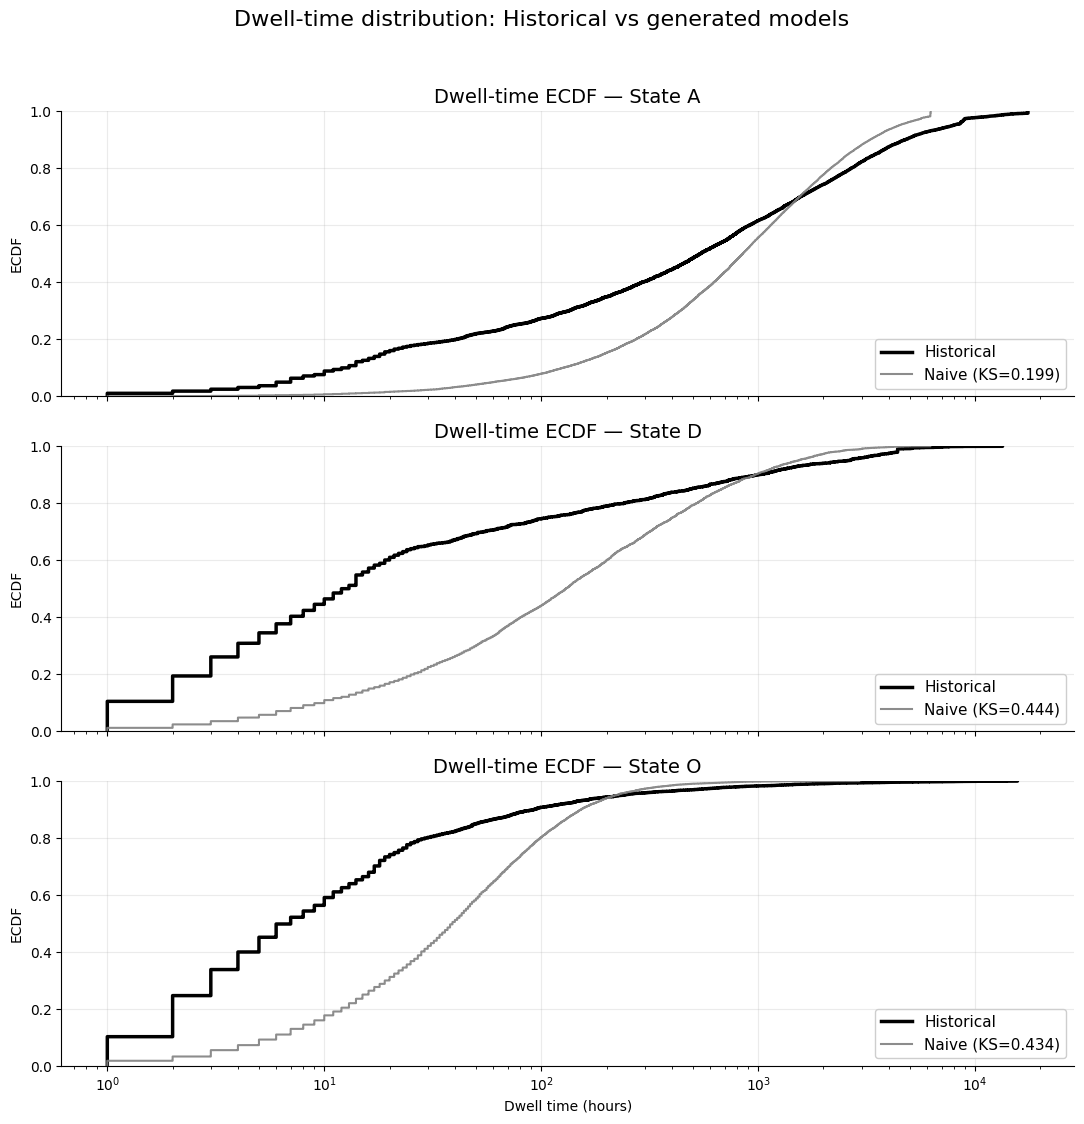

In [24]:
plot_dwelltime_ecdf_by_state(
    historical_dwell_times=historical_dwell_times,
    generated_dwell_times=generated_dwell_times,
    model_colors=model_colors,
    states_order=("A", "D", "O"),
    state_labels={"A": "A", "D": "D", "O": "O"},
    figsize=(11, 11),
    font_base=12,
    model_lw=1.5,
    xscale="log",
)

In [25]:
# Stress reference from inputs
bin_edges = compute_stress_edges_4bins(prep["inputs_by_state"])

# Historical occupancy
state_occupancy_historical = aggregate_historical_state_occupancy(
    historical_scenarios_per_state=historical_scenarios_per_state,
    stress_reference_by_state=prep["inputs_by_state"],
)

historical_mean_occupancy = aggregate_historical_mean_occupancy_by_stress_bin(
    state_occupancy_historical=state_occupancy_historical,
    bin_edges=bin_edges,
)

# Generated occupancy
state_occupancy_generated = aggregate_generated_state_occupancy(
    generated_scenarios_by_state=generated_scenarios_by_state,
    stress_reference_by_state=prep["inputs_by_state"],
)

generated_mean_occupancy = aggregate_generated_mean_occupancy_by_stress_bin(
    state_occupancy_generated=state_occupancy_generated,
    bin_edges=bin_edges,
)

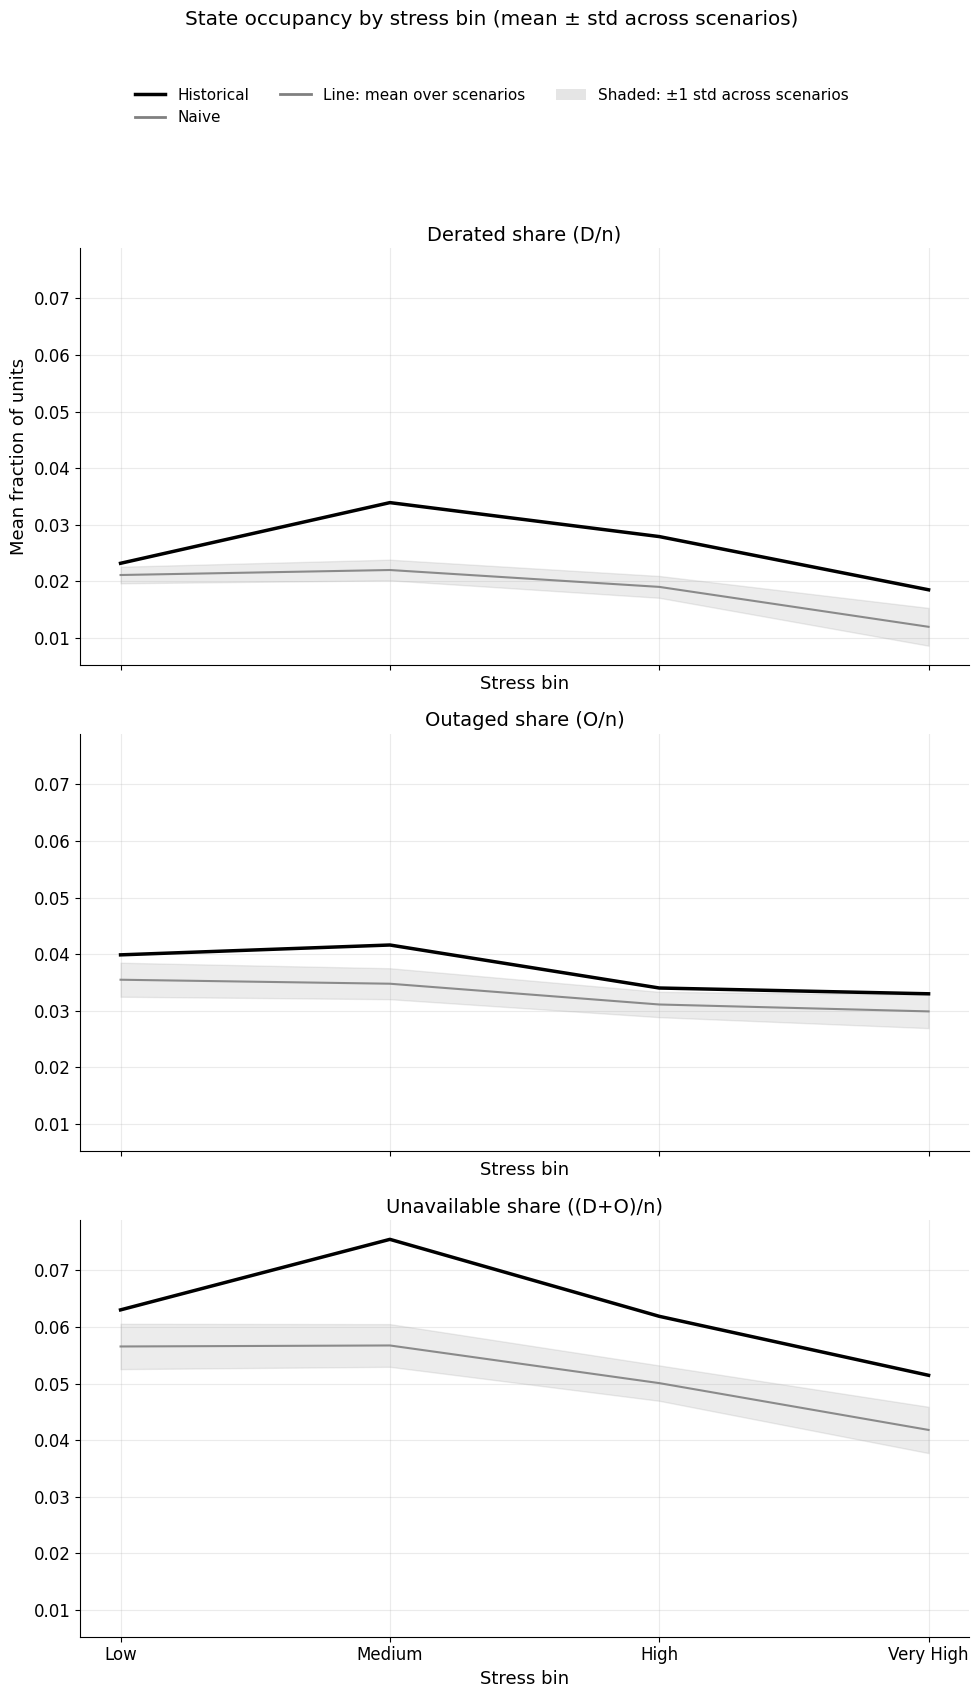

In [26]:
plot_state_occupancy_by_stress_bin(
    historical_mean_occupancy=historical_mean_occupancy,
    generated_mean_occupancy=generated_mean_occupancy,
    model_colors=model_colors,
)